<a href="https://colab.research.google.com/github/amanouz-mounir/Classification-of-Aviation-Incident-reports/blob/main/train_undersampled_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load des embeddings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import joblib

# Charger un modèle ou un objet enregistré en .pkl
X_test = joblib.load("/content/X_test.pkl")
X_train = joblib.load("/content/X_train.pkl")
y_test = joblib.load("/content/y_test.pkl")
y_train = joblib.load("/content/y_train.pkl")



In [ ]:
import numpy as np

X_test = np.load('/content/X_test_embeddings.npy')
X_train = np.load('/content/X_train_embeddings.npy')
y_train = np.load('/content/y_train.npy')
y_test = np.load('/content/y_test.npy')

In [ ]:
import numpy as np

X_test = np.load('/content/X_test_resample.npy')
X_train = np.load('/content/X_train_resample.npy')
y_train = np.load('/content/y_train_resample.npy')
y_test = np.load('/content/y_test_resample.npy')

In [ ]:
import numpy as np

X_test_resample_1 = np.load('/content/X_test_resample_1.npy')
X_train_resample_1 = np.load('/content/X_train_resample_1.npy')
y_train_resample_1 = np.load('/content/y_train_resample_1.npy')
y_test_resample_1 = np.load('/content/y_test_resample_1.npy')

In [ ]:
y_train


array([[0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [ ]:
y_train.shape[1]

22

# Optimization des **hyperparams** XGboost

In [ ]:
pip install iterative-stratification

In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score, make_scorer
import time

def train_multilabel_xgboost(X_train, y_train, n_folds=3, n_iter_search=10):
    """
    Entraîne un modèle XGBoost multi-label avec une recherche d'hyperparamètres optimisée.

    Args:15761
        X_train (np.array): Matrice des features d'entraînement.
        y_train (np.array): Matrice binaire des labels.
        n_folds (int): Nombre de folds pour la validation croisée.
        n_iter_search (int): Nombre d'itérations pour la recherche d'hyperparamètres.

    Returns:
        best_model (XGBClassifier): Modèle XGBoost entraîné et optimisé.
    """

    # Fonction F1-score avec seuil ajusté
    def multi_label_f1(y_true, y_pred):
        return f1_score(y_true, (y_pred > 0.3).astype(int), average='macro')  # Seuil réduit à 0.3

    f1_scorer = make_scorer(multi_label_f1, greater_is_better=True)

    # Définition du modèle de base
    xgb_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",  # Optimisé pour les grandes dimensions
        random_state=42,
        use_label_encoder=False
    )

    # Grille d'hyperparamètres améliorée
    xgb_param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.1, 0.05, 0.01],
        'n_estimators': [200, 300, 500],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.5, 0.7, 0.9],
        'min_child_weight': [1, 3, 5],
        'reg_lambda': [1, 3, 5],
        'reg_alpha': [0, 0.1, 0.5],
        'scale_pos_weight': [1, 5, 10]
    }

    # Validation croisée multi-label
    kf = MultilabelStratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    # Recherche aléatoire des hyperparamètres
    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=xgb_param_grid,
        n_iter=n_iter_search,
        cv=kf,
        scoring=f1_scorer,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True  # Retourner les scores d'entraînement pour affichage
    )

    start_time = time.time()

    # Entraînement et recherche des meilleurs hyperparamètres
    random_search.fit(X_train, y_train)

    # Meilleur modèle trouvé
    best_model = random_search.best_estimator_
    print("Meilleurs hyperparamètres :", random_search.best_params_)

    # Enregistrement du modèle à chaque itération
    for i, model in enumerate(random_search.cv_results_['params']):
        model_filename = f"xgb_model_iter_{i+1}.joblib"
        joblib.dump(random_search.estimator.set_params(**model), model_filename)
        print(f"Modèle de l'itération {i+1} sauvegardé sous '{model_filename}'")

    # Sauvegarde du meilleur modèle
    joblib.dump(best_model, "xgb_model_multilabel_best.joblib")
    print("Meilleur modèle sauvegardé sous 'xgb_model_multilabel_best.joblib'")

    # Performance du modèle sur l'entraînement
    y_train_pred = best_model.predict(X_train)
    train_f1 = f1_score(y_train, (y_train_pred > 0.3).astype(int), average='macro')
    print(f"Score F1 sur les données d'entraînement : {train_f1:.4f}")

    # Graphique des performances au fil des itérations
    plt.figure(figsize=(10, 6))
    plt.plot(random_search.cv_results_['mean_test_score'], label='F1-score moyen (test)')
    plt.plot(random_search.cv_results_['mean_train_score'], label='F1-score moyen (train)')
    plt.title("Courbe d'apprentissage - F1-score")
    plt.xlabel("Itérations")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graphique de l'importance des caractéristiques
    xgb_model = best_model  # Le modèle final
    plt.figure(figsize=(10, 6))
    plt.barh(np.arange(len(xgb_model.feature_importances_)), xgb_model.feature_importances_)
    plt.title("Importance des caractéristiques")
    plt.xlabel("Importance")
    plt.ylabel("Caractéristiques")
    plt.show()

    # Durée de l'entraînement
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Durée totale de l'entraînement et de la recherche : {training_time:.2f} secondes")

    return best_model


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:57:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Meilleurs hyperparamètres : {'subsample': 1.0, 'scale_pos_weight': 5, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Modèle de l'itération 1 sauvegardé sous 'xgb_model_iter_1.joblib'
Modèle de l'itération 2 sauvegardé sous 'xgb_model_iter_2.joblib'
Modèle de l'itération 3 sauvegardé sous 'xgb_model_iter_3.joblib'
Modèle de l'itération 4 sauvegardé sous 'xgb_model_iter_4.joblib'
Modèle de l'itération 5 sauvegardé sous 'xgb_model_iter_5.joblib'
Modèle de l'itération 6 sauvegardé sous 'xgb_model_iter_6.joblib'
Modèle de l'itération 7 sauvegardé sous 'xgb_model_iter_7.joblib'
Modèle de l'itération 8 sauvegardé sous 'xgb_model_iter_8.joblib'
Modèle de l'itération 9 sauvegardé sous 'xgb_model_iter_9.joblib'
Modèle de l'itération 10 sauvegardé sous 'xgb_model_iter_10.joblib'
Meilleur modèle sauvegardé sous 'xgb_model_multilabel_best.joblib'
Score F1 sur les données d'entraînement : 0.9338


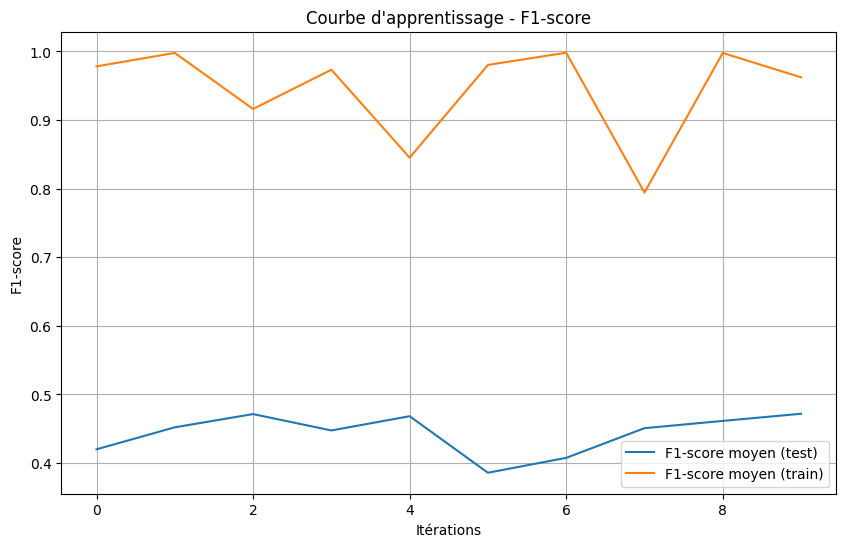

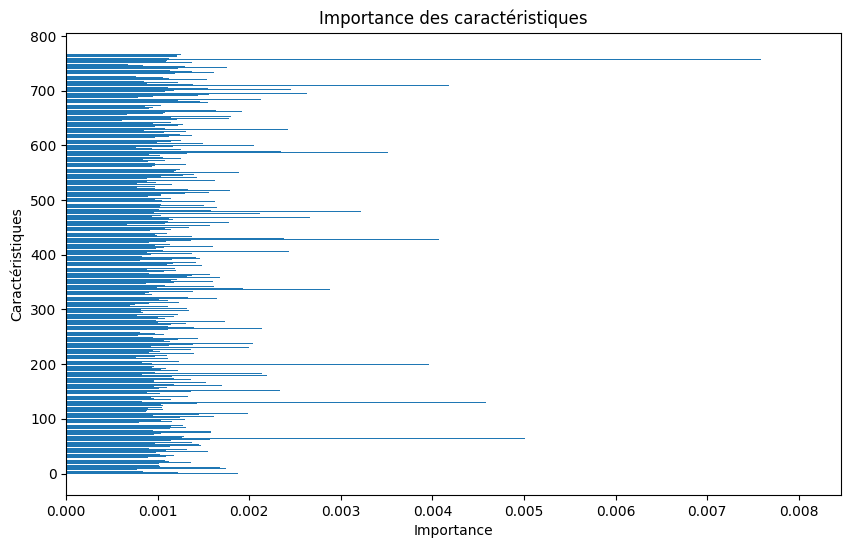

Durée totale de l'entraînement et de la recherche : 13003.52 secondes


In [ ]:
model = train_multilabel_xgboost(X_train, y_train)

Meilleurs hyperparamètres : {'subsample': 1.0, 'scale_pos_weight': 5, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7} \\

> Ajouter une citation


Score F1 sur les données d'entraînement : 0.9338 \\
Durée totale de l'entraînement et de la recherche : 13003.52 secondes


# Optimization hyperparams LGBM

In [ ]:
pip install iterative-stratification

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import RandomizedSearchCV
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import joblib

def train_multilabel_lgbm(X_train, y_train, n_folds=3, n_iter_search=10):
    # Création du modèle LGBM
    lgbm_model = LGBMClassifier(
        objective="binary",  # Classification binaire pour chaque label
        metric="binary_logloss",  # Log loss pour la classification binaire
        random_state=42
    )

    # Application de MultiOutputClassifier pour gérer les labels multiples
    multi_output_model = MultiOutputClassifier(lgbm_model)

    # Configuration de la validation croisée stratifiée pour le multi-label
    kf = MultilabelStratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    # Paramètres pour la recherche aléatoire d'hyperparamètres
    lgbm_param_grid = {
        'estimator__num_leaves': [31, 50, 100],
        'estimator__max_depth': [-1, 5, 10],
        'estimator__learning_rate': [0.01, 0.05, 0.1],
        'estimator__n_estimators': [100, 200, 300],
        'estimator__subsample': [0.8, 0.9, 1.0],
        'estimator__colsample_bytree': [0.5, 0.7, 0.9],
        'estimator__min_child_weight': [1, 3, 5],
        'estimator__reg_lambda': [1, 3, 5],
        'estimator__reg_alpha': [0, 0.1, 0.5],
        'estimator__scale_pos_weight': [1, 5, 10]
    }


    # Recherche aléatoire des meilleurs hyperparamètres
    random_search = RandomizedSearchCV(
        estimator=multi_output_model,
        param_distributions=lgbm_param_grid,
        n_iter=n_iter_search,  # Ajustable selon la puissance de calcul
        cv=kf,
        scoring='f1_micro',  # Ajustable selon l'objectif
        n_jobs=-1,
        verbose=2,
        random_state=42,
        error_score='raise'
    )

    # Entraînement du mLe enviamos nuestro proyecto de audiolibro realizado con Kelvin MARTINEZ y Mounir AMANOUZ.odèle avec la recherche d'hyperparamètres
    random_search.fit(X_train, y_train)

    # Récupérer le meilleur modèle trouvé
    best_model = random_search.best_estimator_
    print("Meilleurs hyperparamètres trouvés:", random_search.best_params_)

    # Sauvegarde du modèle entraîné
    joblib.dump(best_model, "lgbm_model_multilabel_prob.joblib")
    print("Modèle sauvegardé sous 'lgbm_model_multilabel_prob.joblib'")

    return best_model

In [ ]:
train_multilabel_lgbm(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 51, number of negative: 2509
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 2560, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019922 -> initscore=-3.895814
[LightGBM] [Info] Start training from score -3.895814
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1005, number of negative: 1555
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025000 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 2560, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.392578 -> initscore=-0.436488
[LightGBM] [Info] Start training from score -0.436488
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 248, number of negative: 2312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 2560, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.096875 -> initscore=-2.232439
[LightGBM] [Info] Start training from score -2.232439
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 396, number of negative: 2164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 2560, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154688 -> initscore=-1.698299
[LightGBM] [Info] Start training from score -1.698299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

MultiOutputClassifier(estimator=LGBMClassifier(colsample_bytree=0.5,
                                               learning_rate=0.05, max_depth=10,
                                               metric='binary_logloss',
                                               min_child_weight=1,
                                               n_estimators=200, num_leaves=50,
                                               objective='binary',
                                               random_state=42, reg_alpha=0,
                                               reg_lambda=5,
                                               scale_pos_weight=10,
                                               subsample=0.9))

Meilleurs hyperparamètres trouvés: {'estimator__subsample': 0.9, 'estimator__scale_pos_weight': 10, 'estimator__reg_lambda': 5, 'estimator__reg_alpha': 0, 'estimator__num_leaves': 50, 'estimator__n_estimators': 200, 'estimator__min_child_weight': 1, 'estimator__max_depth': 10, 'estimator__learning_rate': 0.05, 'estimator__colsample_bytree': 0.5} //


# Optimisation **SVM**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from collections import Counter
import joblib  # Importation de joblib pour la sauvegarde du modèle

def optimize_svm_hyperparameters(X_train_embeddings, y_train):
    """
    Perform grid search to find optimal SVM parameters for multi-label classification.

    Args:
        X_train_embeddings: BERT embeddings for training data
        y_train: Training labels (multi-label binary array)
    Returns:
        best_estimator_: Trained SVM model with optimal hyperparameters
    """
    param_grid = {
        'estimator__C': [1],
        'estimator__kernel': ['rbf']
    }

    svm = SVC(probability=True)  # Enable probability for confidence scores if needed
    multi_label_svm = MultiOutputClassifier(svm)

    print("Performing grid search...")
    grid_search = GridSearchCV(multi_label_svm, param_grid, cv=3, n_jobs=-1, verbose=2)
    grid_search.fit(X_train_embeddings, y_train)

    print("\nBest parameters:", grid_search.best_params_)
    print("Best cross-validation score:", grid_search.best_score_)

    return grid_search.best_estimator_

def train_svm_classifier(X_train_embeddings, X_test_embeddings, y_train, y_test, class_names=None, model_filename=None):
    """
    Train and evaluate an SVM classifier for multi-label classification.

    Args:
        X_train_embeddings: BERT embeddings for training data
        X_test_embeddings: BERT embeddings for test data
        y_train: Training labels (multi-label binary array)
        y_test: Test labels (multi-label binary array)
        class_names: Optional list of class names for reporting
        model_filename: Optional file name to save the trained model
    Returns:
        multi_label_svm: Trained SVM model
    """
    # Initialize SVM with default parameters (to be updated with best_estimator_)
    svm = SVC(kernel='rbf', C=1.0, probability=True)
    multi_label_svm = MultiOutputClassifier(svm, n_jobs=-1)

    # Train the model
    print("Training SVM classifier...")
    multi_label_svm.fit(X_train_embeddings, y_train)

    # Make predictions
    print("Making predictions...")
    y_pred = multi_label_svm.predict(X_test_embeddings)

    # Compute evaluation metrics
    hamming_loss_value = hamming_loss(y_test, y_pred)
    exact_match_ratio = accuracy_score(y_test, y_pred)
    print(f"\nHamming Loss: {hamming_loss_value:.4f}")
    print(f"Exact Match Ratio: {exact_match_ratio:.4f}")

    # Per-class performance
    print("\nClassification Report for Each Class:")
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(y_test.shape[1])]
    for i, name in enumerate(class_names):
        print(f"\nPerformance for {name}:")
        print(classification_report(y_test[:, i], y_pred[:, i]))

    # Visualize label combinations
    print("Generating 3D visualization of label combinations...")
    visualize_label_combinations(y_test, y_pred)

    # Save the model if a filename is provided
    if model_filename:
        print(f"Saving the trained model to {model_filename}...")
        joblib.dump(multi_label_svm, model_filename)

    return multi_label_svm

def visualize_label_combinations(y_true, y_pred):
    """
    Visualize unique label combinations in 3D using PCA, colored by prediction accuracy.

    Args:
        y_true: True labels (n_samples, n_classes)
        y_pred: Predicted labels (n_samples, n_classes)
    """
    # Convert label vectors to strings for unique combinations
    true_combinations = [''.join(map(str, row)) for row in y_true]
    pred_combinations = [''.join(map(str, row)) for row in y_pred]
    unique_combs = sorted(set(true_combinations))

    # Compute percentage of correct predictions per combination
    correct_percentages = {}
    for comb in unique_combs:
        indices = [i for i, tc in enumerate(true_combinations) if tc == comb]
        total = len(indices)
        correct = sum(1 for i in indices if true_combinations[i] == pred_combinations[i])
        correct_percentages[comb] = (correct / total) * 100 if total > 0 else 0

    # Convert combinations to binary arrays for PCA
    unique_comb_arrays = np.array([[int(bit) for bit in comb] for comb in unique_combs])

    # Reduce to 3D with PCA
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(unique_comb_arrays)

    # Create 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    percentages = [correct_percentages[comb] for comb in unique_combs]
    scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2],
                         c=percentages, cmap='viridis', s=50)

    # Add color bar and labels
    plt.colorbar(scatter).set_label('Percentage of Correct Predictions (%)')
    ax.set_title('3D Plot of Unique Label Combinations')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.set_zlabel('PCA Component 3')
    plt.show()

def run_svm_classification(X_train_resample, y_train_resample, X_test_resample, y_test_resample, class_names=None, model_filename=None):
    """
    Run the complete SVM classification pipeline with hyperparameter optimization.

    Args:
        X_embeddings: Full set of embeddings
        y: Full set of labels (multi-label binary array)
        class_names: Optional list of class names for reporting
        model_filename: Optional file name to save the trained model
    Returns:
        final_model: Trained SVM model with optimal parameters
    """
    # Split data
    X_train_embeddings, X_test_embeddings, y_train, y_test = X_train_resample, X_test_resample, y_train_resample, y_test_resample

    # Optimize hyperparameters
    best_model = optimize_svm_hyperparameters(X_train_embeddings, y_train)

    # Train and evaluate with best model
    final_model = train_svm_classifier(X_train_embeddings, X_test_embeddings, y_train, y_test, class_names, model_filename)

    return final_model


Performing grid search...
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best parameters: {'estimator__C': 1, 'estimator__kernel': 'rbf'}
Best cross-validation score: 0.11132632862112231
Training SVM classifier...
Making predictions...

Hamming Loss: 0.0996
Exact Match Ratio: 0.1359

Classification Report for Each Class:

Performance for Class_0:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       626
           1       1.00      0.07      0.13        14

    accuracy                           0.98       640
   macro avg       0.99      0.54      0.56       640
weighted avg       0.98      0.98      0.97       640


Performance for Class_1:
              precision    recall  f1-score   support

           0       0.64      0.87      0.74       354
           1       0.71      0.40      0.51       286

    accuracy                           0.66       640
   macro avg       0.68      0.63      0.62       640
weighted avg 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

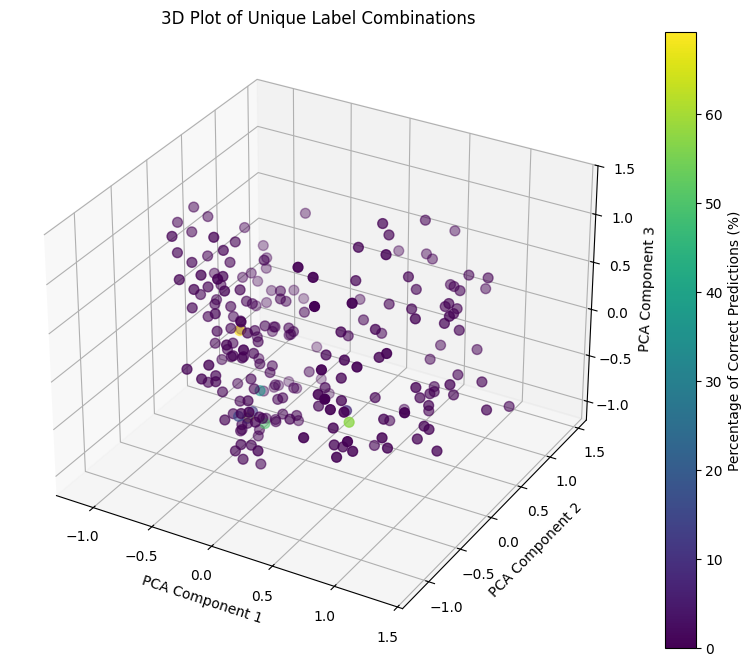

In [ ]:
svm_model = run_svm_classification(X_train,y_train,X_test,y_test)

# Entrainement avec les meilleurs hypersparams

In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import time

def train_best_xgboost(X_train, y_train, threshold=0.3):
    """
    Entraîne un modèle XGBoost multi-label avec les meilleurs hyperparamètres trouvés.

    Args:
        X_train (np.array): Matrice des features d'entraînement.
        y_train (np.array): Matrice binaire des labels d'entraînement.
        X_test (np.array, optional): Matrice des features de test.
        y_test (np.array, optional): Matrice binaire des labels de test.
        threshold (float, optional): Seuil de classification pour binariser les prédictions.

    Returns:
        best_model (XGBClassifier): Modèle XGBoost entraîné.
    """
    best_params = {
        'subsample': 1.0,
        'scale_pos_weight': 5,
        'reg_lambda': 5,
        'reg_alpha': 0,
        'n_estimators': 500,
        'min_child_weight': 3,
        'max_depth': 4,
        'learning_rate': 0.01,
        'colsample_bytree': 0.7,
        'objective': "binary:logistic",
        'eval_metric': "logloss",
        'tree_method': "hist",
        'random_state': 42,
        'use_label_encoder': False
    }

    start_time = time.time()

    # Initialisation et entraînement du modèle
    model = XGBClassifier(**best_params)
    model.fit(X_train, y_train)

    # Sauvegarde du modèle entraîné
    joblib.dump(model, "xgb_model_data_resample_1.joblib")
    print("Modèle entraîné sauvegardé sous 'xgb_model_data_resample_1.joblib'")

    # Évaluation sur les données d'entraînement
    y_train_pred = model.predict(X_train)
    train_f1 = f1_score(y_train, (y_train_pred > threshold).astype(int), average='macro')
    print(f"Score F1 sur les données d'entraînement : {train_f1:.4f}")


    # Importance des caractéristiques
    plt.figure(figsize=(10, 6))
    plt.barh(np.arange(len(model.feature_importances_)), model.feature_importances_)
    plt.title("Importance des caractéristiques")
    plt.xlabel("Importance")
    plt.ylabel("Caractéristiques")
    plt.show()

    end_time = time.time()
    print(f"Durée totale de l'entraînement : {end_time - start_time:.2f} secondes")

    return model


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier
import joblib

def train_best_lgbm(X_train, y_train):
    # Définition des meilleurs hyperparamètres trouvés
    best_params = {
        'num_leaves': 50,
        'max_depth': 10,
        'learning_rate': 0.05,
        'n_estimators': 200,
        'subsample': 0.9,
        'colsample_bytree': 0.5,
        'min_child_weight': 1,
        'reg_lambda': 5,
        'reg_alpha': 0,
        'scale_pos_weight': 10,
        'objective': "binary",
        'metric': "binary_logloss",
        'random_state': 42,
        'verbose': -1,

    }

    # Création du modèle LGBM avec les meilleurs hyperparamètres
    lgbm_model = LGBMClassifier(**best_params)

    # Application de MultiOutputClassifier pour gérer les labels multiples
    multi_output_model = MultiOutputClassifier(lgbm_model)

    # Entraînement du modèle
    multi_output_model.fit(X_train, y_train)

    # Sauvegarde du modèle entraîné
    joblib.dump(multi_output_model, "lgbm_model_data_resample_1.joblib")
    print("Modèle entraîné et sauvegardé sous 'lgbm_model_best.joblib'")

    return multi_output_model


**Entrainer le model XGboost avec les meilleurs hyperparams sur les donnees undersample**

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:16:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Modèle entraîné sauvegardé sous 'xgb_model_best_trained.joblib'
Score F1 sur les données d'entraînement : 0.9732


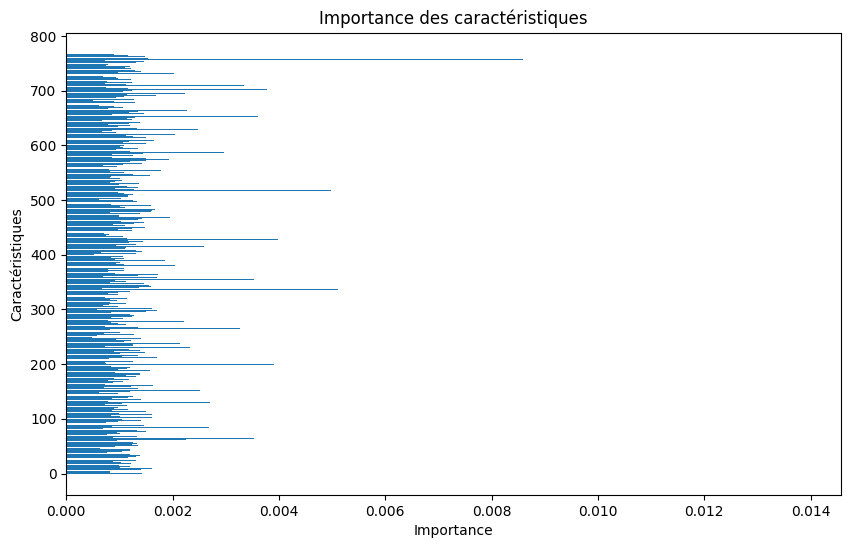

Durée totale de l'entraînement : 738.00 secondes


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
train_best_xgboost(X_train_resample_1, y_train_resample_1)

**Entrainer le model LGBM avec les meilleurs hyperparams sur les donnees undersample**

In [ ]:
train_best_lgbm(X_train_resample_1, y_train_resample_1)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Modèle entraîné et sauvegardé sous 'lgbm_model_best.joblib'


MultiOutputClassifier(estimator=LGBMClassifier(colsample_bytree=0.5,
                                               learning_rate=0.05, max_depth=10,
                                               metric='binary_logloss',
                                               min_child_weight=1,
                                               n_estimators=200, num_leaves=50,
                                               objective='binary',
                                               random_state=42, reg_alpha=0,
                                               reg_lambda=5,
                                               scale_pos_weight=10,
                                               subsample=0.9, verbose=-1))

# Evaluation du classifier

In [ ]:
import joblib

# Load the trained model
xgb_model = joblib.load("/content/xgb_model_multilabel_best.joblib")
lgbm_model = joblib.load("/content/lgbm_model_multilabel_prob.joblib")
#xgb_model_resample_1 = joblib.load("/content/xgb_model_data_resample_1.joblib")
#lgbm_model_data_resample_1 = joblib.load("/content/lgbm_model_data_resample_1.joblib")

In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss

def evaluate(model, X_test, y_test, class_names=None, threshold=0.5):
    """
    Évalue le modèle XGBoost multi-label et affiche :
    1. Une matrice de confusion 22x22
    2. Un graphique des métriques (F1-score, précision, rappel) bien structuré.
    3. La Hamming Loss, le Matching Ratio, et les classes ratées par prédiction.

    Args:
        model (sklearn model): Le modèle entraîné.
        X_test (np.array): Matrice des caractéristiques de test.
        y_test (np.array): Vraies étiquettes sous forme de matrice 2D (lignes = échantillons, colonnes = classes).
        class_names (list, optional): Liste des noms de classes.
        threshold (float, optional): Seuil pour prédire les classes.

    Returns:
        dict: Contient les scores F1, précision, rappel, Hamming Loss et Matching Ratio.
    """

    # Prédictions
    try:
        y_pred_proba = model.predict_proba(X_test)
    except AttributeError:
        raise ValueError("Le modèle ne prend pas en charge 'predict_proba'. Assurez-vous que le modèle est configuré correctement.")

    y_pred = (y_pred_proba > threshold).astype(int)

    # Calcul des métriques classiques
    f1_per_class = f1_score(y_test, y_pred, average=None)
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)

    # Moyennes des métriques
    avg_f1 = np.mean(f1_per_class)
    avg_precision = np.mean(precision_per_class)
    avg_recall = np.mean(recall_per_class)

    # Hamming Loss
    hamming_loss_value = hamming_loss(y_test, y_pred)

    # Matching Ratio
    matching_ratio = np.mean(np.all(y_test == y_pred, axis=1))

    # Calcul des classes ratées pour chaque prédiction
    missed_classes_per_sample = np.sum((y_test == 1) & (y_pred == 0), axis=1)

    # Afficher un résumé des métriques
    print(f"\n Moyenne des scores : F1 = {avg_f1:.4f} | Précision = {avg_precision:.4f} | Rappel = {avg_recall:.4f}")
    print(f"Hamming Loss : {hamming_loss_value:.4f}")
    print(f"Matching Ratio : {matching_ratio:.4f}")
    print(f"Classes ratées par prédiction (moyenne) : {np.mean(missed_classes_per_sample):.2f}")

    # Définition des noms des classes si absents
    if class_names is None:
        class_names = [f"Classe {i}" for i in range(y_test.shape[1])]

    # Graphique des métriques
    metrics_df = pd.DataFrame({
        "Classe": class_names,
        "F1-score": f1_per_class,
        "Précision": precision_per_class,
        "Rappel": recall_per_class
    })

    metrics_df.set_index("Classe", inplace=True)
    ax = metrics_df.plot(kind="bar", figsize=(14, 6), colormap="tab10", width=0.8, edgecolor="black")

    # Ajout des annotations pour les moyennes
    plt.axhline(avg_f1, color='blue', linestyle='dashed', linewidth=1, label=f"Moyenne F1: {avg_f1:.3f}")
    plt.axhline(avg_precision, color='green', linestyle='dashed', linewidth=1, label=f"Moyenne Précision: {avg_precision:.3f}")
    plt.axhline(avg_recall, color='red', linestyle='dashed', linewidth=1, label=f"Moyenne Rappel: {avg_recall:.3f}")

    # Ajout des légendes
    plt.title("Scores F1, Précision et Rappel par Classe")
    plt.ylabel("Score")
    plt.xlabel("Classe")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

    # Graphique des classes ratées par prédiction
    plt.figure(figsize=(10, 6))
    plt.hist(missed_classes_per_sample, bins=range(0, y_test.shape[1] + 1), align="left", color="orange", edgecolor="black")
    plt.title("Distribution des Classes Ratées par Prédiction")
    plt.xlabel("Nombre de Classes Ratées")
    plt.ylabel("Fréquence")
    plt.xticks(range(0, y_test.shape[1] + 1))
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()



In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss

def evaluate_lgbm(model, X_test, y_test, class_names=None, threshold=0.33):
    """
    Évalue le modèle LightGBM multi-label et affiche :
    1. Une matrice de confusion.
    2. Un graphique des métriques (F1-score, précision, rappel).
    3. La Hamming Loss, le Matching Ratio, et les classes ratées par prédiction.

    Args:
        model (sklearn model): Le modèle entraîné.
        X_test (np.array): Matrice des caractéristiques de test.
        y_test (np.array): Vraies étiquettes sous forme de matrice 2D.
        class_names (list, optional): Liste des noms de classes.
        threshold (float, optional): Seuil pour prédire les classes.

    Returns:
        dict: Contient les scores F1, précision, rappel, Hamming Loss et Matching Ratio.
    """
    # Prédictions des probabilités pour chaque label
    y_pred_proba = np.column_stack([clf.predict_proba(X_test)[:, 1] for clf in model.estimators_])
    y_pred = (y_pred_proba > threshold).astype(int)

    # Calcul des métriques
    f1_per_class = f1_score(y_test, y_pred, average=None)
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)

    avg_f1 = np.mean(f1_per_class)
    avg_precision = np.mean(precision_per_class)
    avg_recall = np.mean(recall_per_class)

    hamming_loss_value = hamming_loss(y_test, y_pred)
    matching_ratio = np.mean(np.all(y_test == y_pred, axis=1))

    missed_classes_per_sample = np.sum((y_test == 1) & (y_pred == 0), axis=1)

    print(f"\n Moyenne des scores : F1 = {avg_f1:.4f} | Précision = {avg_precision:.4f} | Rappel = {avg_recall:.4f}")
    print(f"Hamming Loss : {hamming_loss_value:.4f}")
    print(f"Matching Ratio : {matching_ratio:.4f}")
    print(f"Classes ratées par prédiction (moyenne) : {np.mean(missed_classes_per_sample):.2f}")

    if class_names is None:
        class_names = [f"Classe {i}" for i in range(y_test.shape[1])]

    # Graphique des métriques
    metrics_df = pd.DataFrame({
        "Classe": class_names,
        "F1-score": f1_per_class,
        "Précision": precision_per_class,
        "Rappel": recall_per_class
    })

    metrics_df.set_index("Classe", inplace=True)
    ax = metrics_df.plot(kind="bar", figsize=(14, 6), colormap="tab10", width=0.8, edgecolor="black")

    plt.axhline(avg_f1, color='blue', linestyle='dashed', linewidth=1, label=f"Moyenne F1: {avg_f1:.3f}")
    plt.axhline(avg_precision, color='green', linestyle='dashed', linewidth=1, label=f"Moyenne Précision: {avg_precision:.3f}")
    plt.axhline(avg_recall, color='red', linestyle='dashed', linewidth=1, label=f"Moyenne Rappel: {avg_recall:.3f}")

    plt.title("Scores F1, Précision et Rappel par Classe")
    plt.ylabel("Score")
    plt.xlabel("Classe")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

    # Distribution des classes ratées
    plt.figure(figsize=(10, 6))
    plt.hist(missed_classes_per_sample, bins=range(0, y_test.shape[1] + 1), align="left", color="orange", edgecolor="black")
    plt.title("Distribution des Classes Ratées par Prédiction")
    plt.xlabel("Nombre de Classes Ratées")
    plt.ylabel("Fréquence")
    plt.xticks(range(0, y_test.shape[1] + 1))
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    return {
        "f1_score": avg_f1,
        "precision": avg_precision,
        "recall": avg_recall,
        "hamming_loss": hamming_loss_value,
        "matching_ratio": matching_ratio
    }


**Evaluer le model XGboost avec les donnees undersample**


 Moyenne des scores : F1 = 0.5332 | Précision = 0.6920 | Rappel = 0.4914
Hamming Loss : 0.0989
Matching Ratio : 0.2250
Classes ratées par prédiction (moyenne) : 1.02


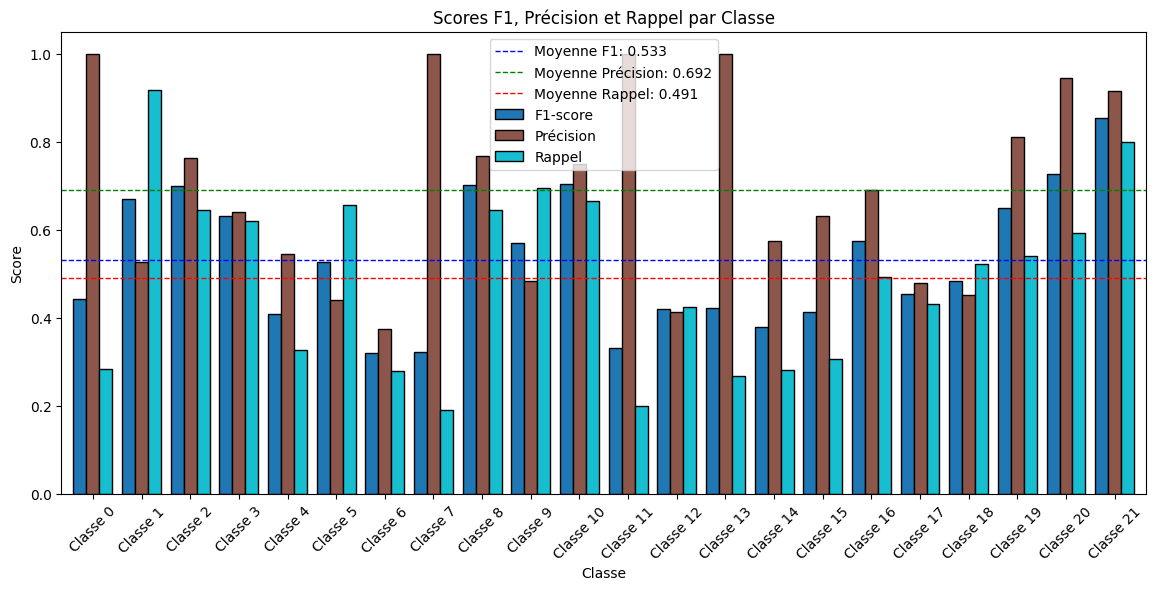

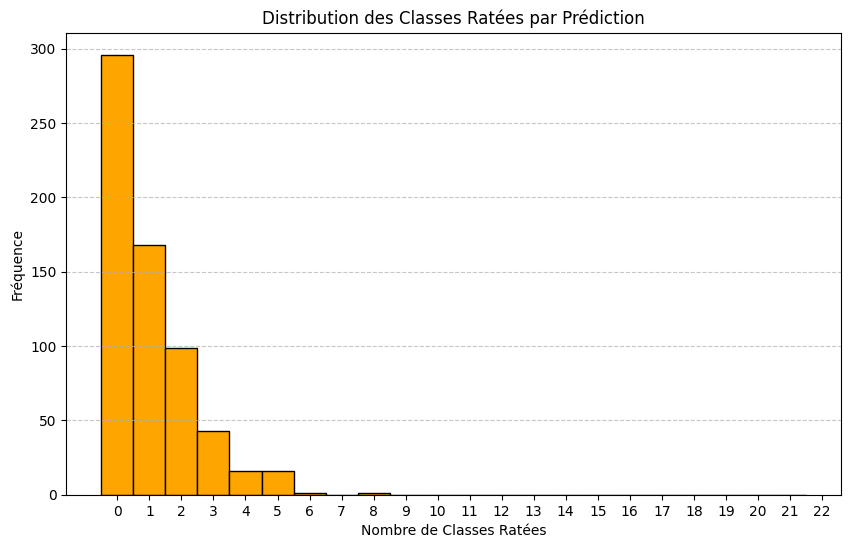

In [ ]:
evaluate(xgb_model, X_test, y_test)

**Evaluer le model XGboost avec les donnees undersample_1**

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Moyenne des scores : F1 = 0.5165 | Précision = 0.6221 | Rappel = 0.4747
Hamming Loss : 0.0511
Matching Ratio : 0.3942
Classes ratées par prédiction (moyenne) : 0.66


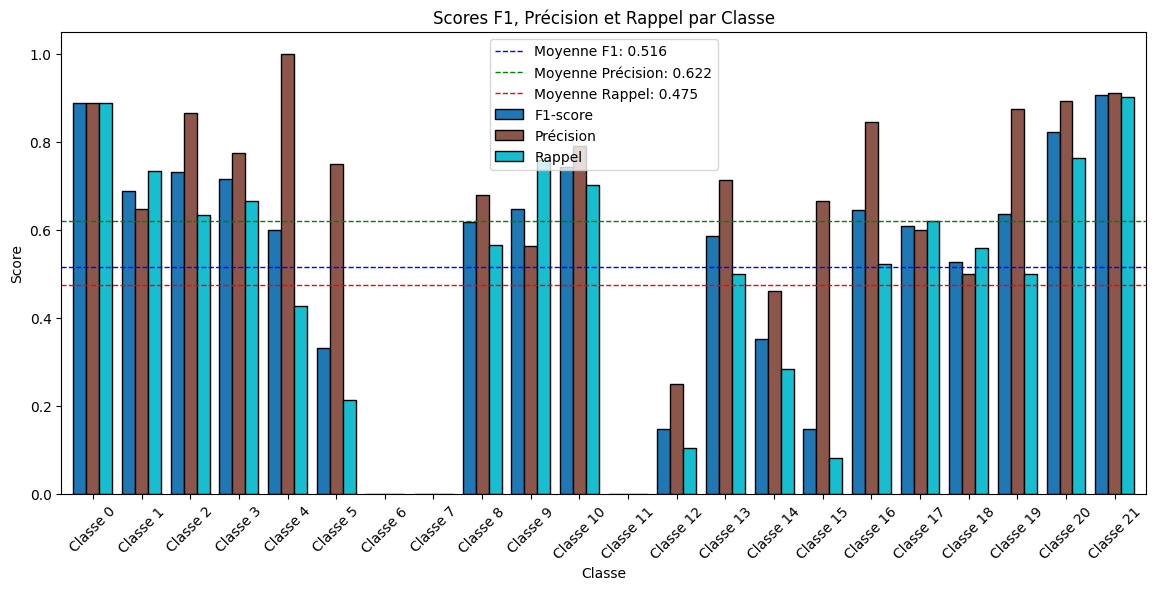

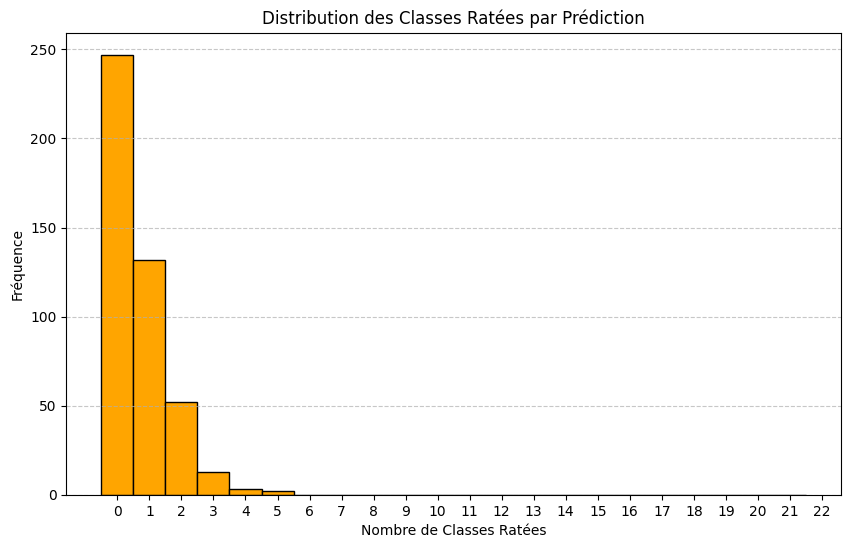

In [ ]:
evaluate(xgb_model_resample_1, X_test_resample_1, y_test_resample_1)

**Evaluer LGBM avec les donnees undersample**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


 Moyenne des scores : F1 = 0.5551 | Précision = 0.6973 | Rappel = 0.5021
Hamming Loss : 0.0884
Matching Ratio : 0.2891
Classes ratées par prédiction (moyenne) : 1.02


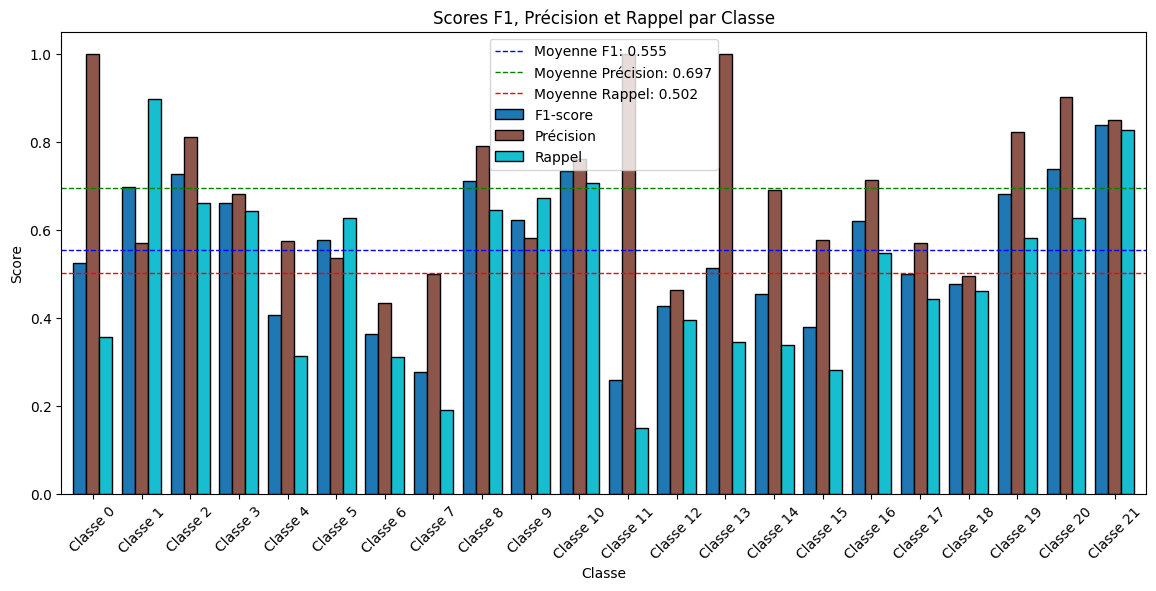

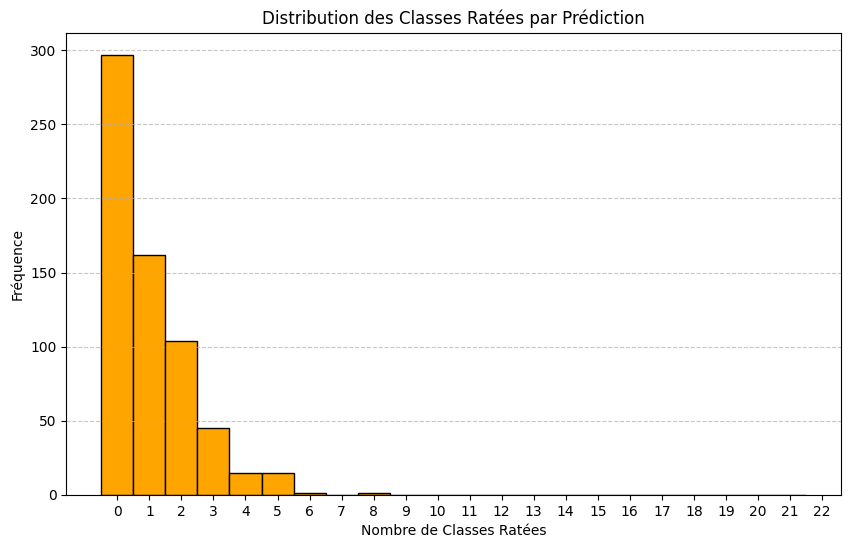

{'f1_score': 0.5551091766322483,
 'precision': 0.6972964588667083,
 'recall': 0.502065812417518,
 'hamming_loss': 0.08835227272727272,
 'matching_ratio': 0.2890625}

In [ ]:
evaluate_lgbm(lgbm_model, X_test, y_test)


**Evaluer LGBM avec les donnees undersample_1**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


 Moyenne des scores : F1 = 0.5449 | Précision = 0.5923 | Rappel = 0.5222
Hamming Loss : 0.0495
Matching Ratio : 0.4410
Classes ratées par prédiction (moyenne) : 0.59


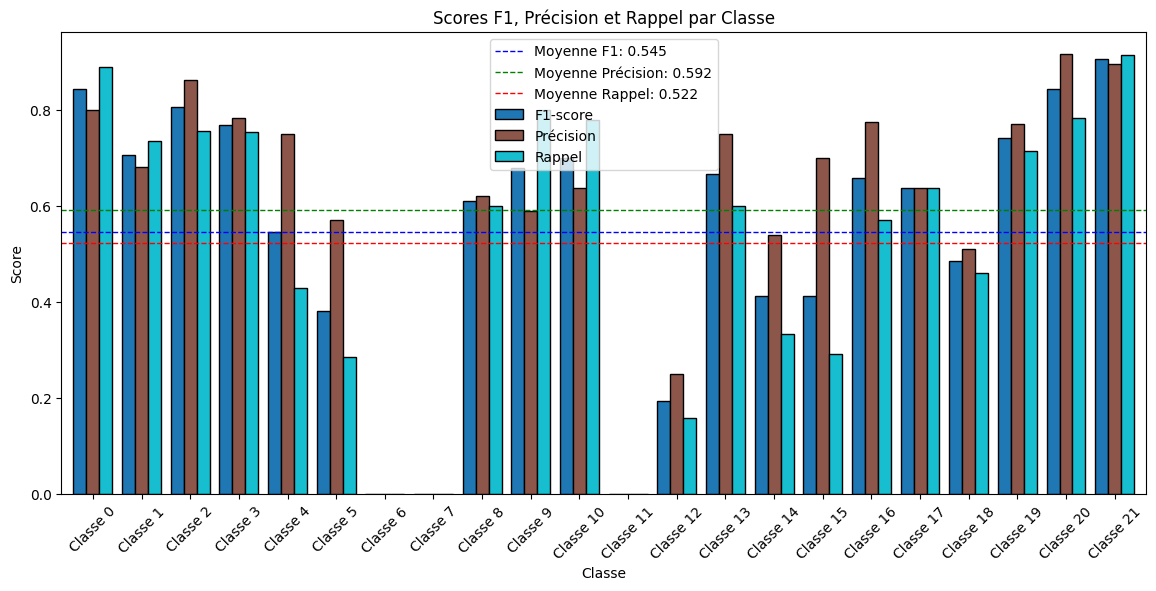

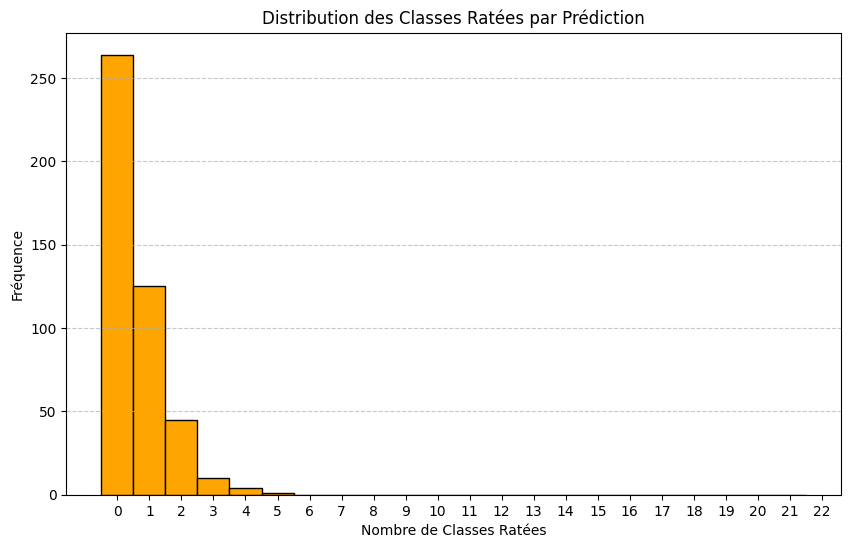

{'f1_score': 0.5448925589660994,
 'precision': 0.5922969445301742,
 'recall': 0.5221948143026155,
 'hamming_loss': 0.04950394816764527,
 'matching_ratio': 0.44097995545657015}

In [ ]:
evaluate_lgbm(lgbm_model_data_resample_1, X_test_resample_1, y_test_resample_1)

In [ ]:
!pip install shap

In [ ]:
import shap  # ajout à l'import
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss

def evaluate_interpret(model, X_test, y_test, class_names=None, threshold=0.5, shap_explain=True, sample_index=0):
    """
    Évalue le modèle et interprète avec SHAP (si activé).
    """

    # Prédictions
    try:
        y_pred_proba = model.predict_proba(X_test)
    except AttributeError:
        raise ValueError("Le modèle ne prend pas en charge 'predict_proba'. Assurez-vous que le modèle est configuré correctement.")

    y_pred = (y_pred_proba > threshold).astype(int)

    # Calcul des métriques
    f1_per_class = f1_score(y_test, y_pred, average=None)
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)

    avg_f1 = np.mean(f1_per_class)
    avg_precision = np.mean(precision_per_class)
    avg_recall = np.mean(recall_per_class)

    hamming_loss_value = hamming_loss(y_test, y_pred)
    matching_ratio = np.mean(np.all(y_test == y_pred, axis=1))
    missed_classes_per_sample = np.sum((y_test == 1) & (y_pred == 0), axis=1)

    print(f"\n Moyenne des scores : F1 = {avg_f1:.4f} | Précision = {avg_precision:.4f} | Rappel = {avg_recall:.4f}")
    print(f"Hamming Loss : {hamming_loss_value:.4f}")
    print(f"Matching Ratio : {matching_ratio:.4f}")
    print(f"Classes ratées par prédiction (moyenne) : {np.mean(missed_classes_per_sample):.2f}")

    if class_names is None:
        class_names = [f"Classe {i}" for i in range(y_test.shape[1])]

    # Graphique des métriques
    metrics_df = pd.DataFrame({
        "Classe": class_names,
        "F1-score": f1_per_class,
        "Précision": precision_per_class,
        "Rappel": recall_per_class
    })

    metrics_df.set_index("Classe", inplace=True)
    ax = metrics_df.plot(kind="bar", figsize=(14, 6), colormap="tab10", width=0.8, edgecolor="black")
    plt.axhline(avg_f1, color='blue', linestyle='dashed', linewidth=1, label=f"Moyenne F1: {avg_f1:.3f}")
    plt.axhline(avg_precision, color='green', linestyle='dashed', linewidth=1, label=f"Moyenne Précision: {avg_precision:.3f}")
    plt.axhline(avg_recall, color='red', linestyle='dashed', linewidth=1, label=f"Moyenne Rappel: {avg_recall:.3f}")
    plt.title("Scores F1, Précision et Rappel par Classe")
    plt.ylabel("Score")
    plt.xlabel("Classe")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

    # Histogramme des classes ratées
    plt.figure(figsize=(10, 6))
    plt.hist(missed_classes_per_sample, bins=range(0, y_test.shape[1] + 1), align="left", color="orange", edgecolor="black")
    plt.title("Distribution des Classes Ratées par Prédiction")
    plt.xlabel("Nombre de Classes Ratées")
    plt.ylabel("Fréquence")
    plt.xticks(range(0, y_test.shape[1] + 1))
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # 🎯 SHAP Interpretation
    if shap_explain:
        print("\n[SHAP] Interprétation des prédictions :")
        try:
            explainer = shap.Explainer(model, X_test)
            shap_values = explainer(X_test)

            # Summary plot global
            shap.summary_plot(shap_values, X_test, plot_type="bar")

            # Explication locale pour un exemple donné
            print(f"\n[SHAP] Explication locale pour l'échantillon index {sample_index} :")
            shap.plots.waterfall(shap_values[sample_index], max_display=10)

        except Exception as e:
            print(f"[SHAP] Une erreur s’est produite lors de l’explication SHAP : {e}")

    return {
        "avg_f1": avg_f1,
        "avg_precision": avg_precision,
        "avg_recall": avg_recall,
        "hamming_loss": hamming_loss_value,
        "matching_ratio": matching_ratio
    }



 Moyenne des scores : F1 = 0.5332 | Précision = 0.6920 | Rappel = 0.4914
Hamming Loss : 0.0989
Matching Ratio : 0.2250
Classes ratées par prédiction (moyenne) : 1.02


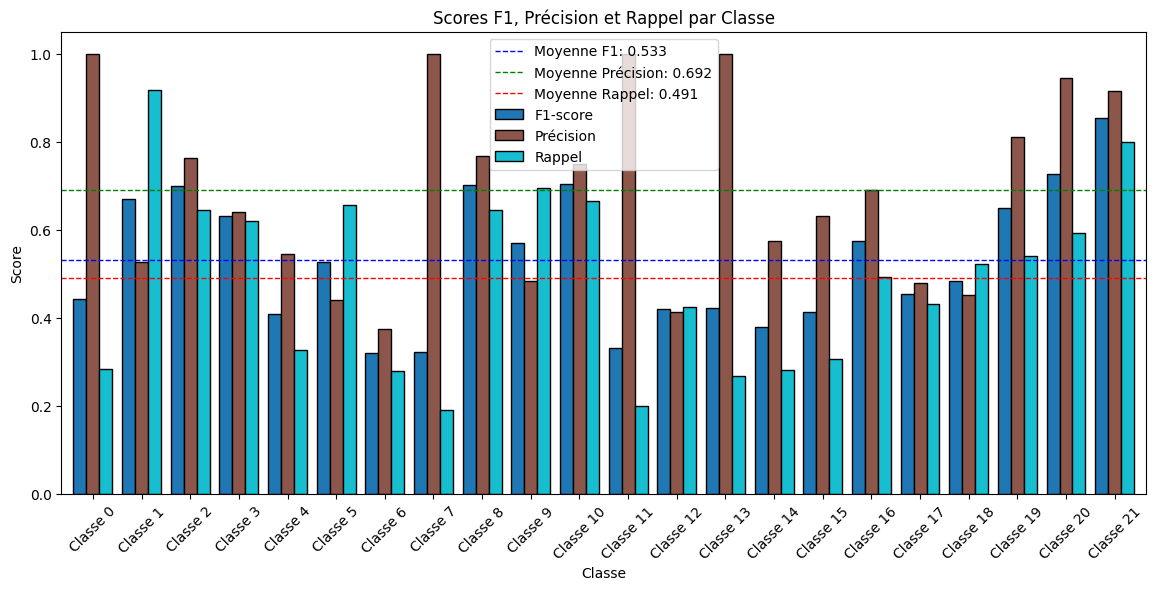

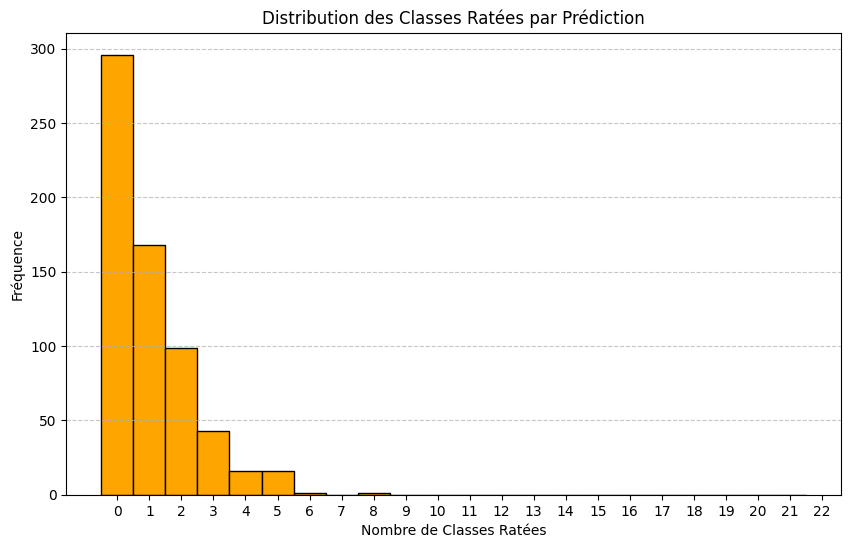


[SHAP] Interprétation des prédictions :


100%|===================| 14078/14080 [115:29<00:00]       

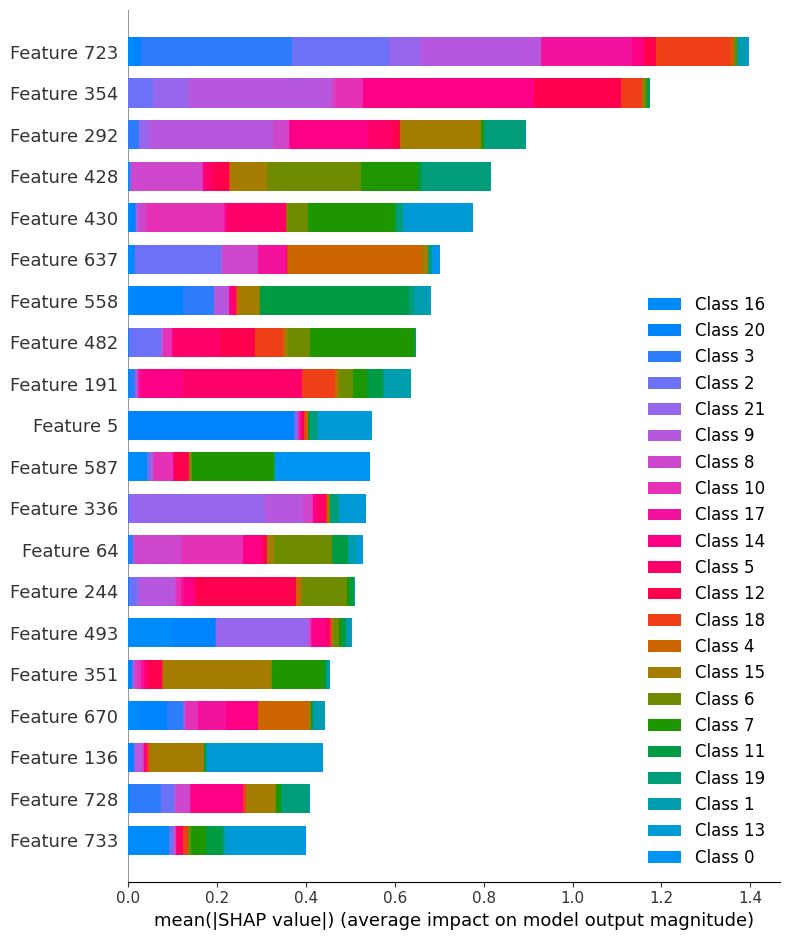


[SHAP] Explication locale pour l'échantillon index 0 :
[SHAP] Une erreur s’est produite lors de l’explication SHAP : The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (768, 22)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


{'avg_f1': np.float64(0.5332110361488571),
 'avg_precision': np.float64(0.6919682785960366),
 'avg_recall': np.float64(0.49140272582880357),
 'hamming_loss': 0.09886363636363636,
 'matching_ratio': np.float64(0.225)}

In [ ]:
evaluate_interpret(xgb_model, X_test, y_test)